# Titanic Dataset - Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the Titanic dataset to understand its structure, identify missing values, analyze numerical and categorical features, detect outliers, and discover relationships between variables before applying machine learning models.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
df = pd.read_csv("../datasets/Titanic-Dataset.csv")

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.shape

(891, 12)

In [13]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [18]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data Quality Checks

In [20]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [22]:
(df.isnull().sum()/df.shape[0])*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

# Univariate Analysis

## Age Distribution

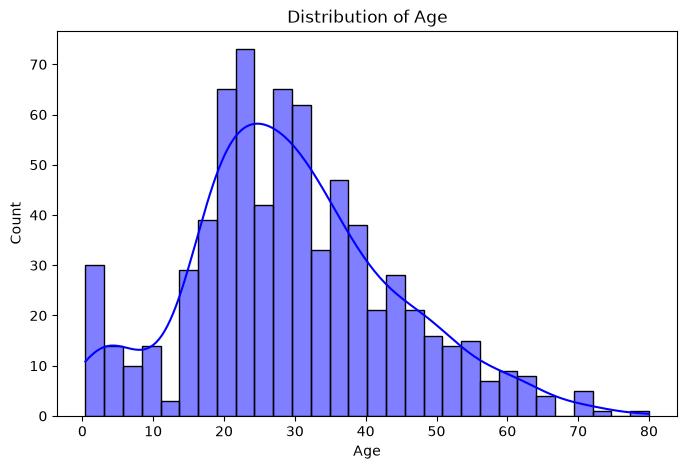

In [28]:
plt.figure(figsize = (8,5))
sns.histplot(df["Age"], bins = 30 , kde = True, color ="blue")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Age Boxplot

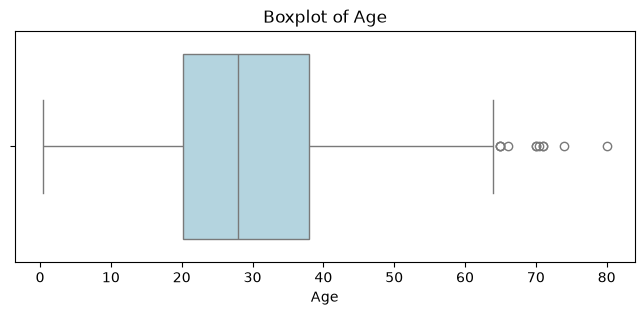

In [31]:
plt.figure(figsize = (8, 3))
sns.boxplot(x = df["Age"], color = "lightblue")
plt.title("Boxplot of Age")
plt.xlabel("Age")
plt.show()

## Fare Distribution

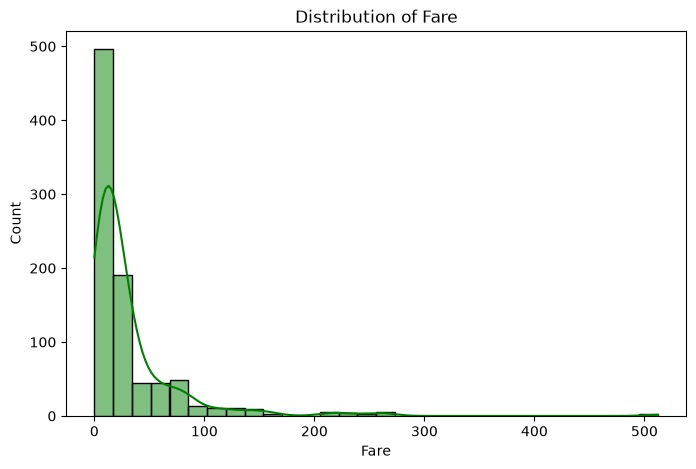

In [33]:
plt.figure(figsize = (8,5))
sns.histplot(df["Fare"], bins = 30 , kde = True, color ="green")
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

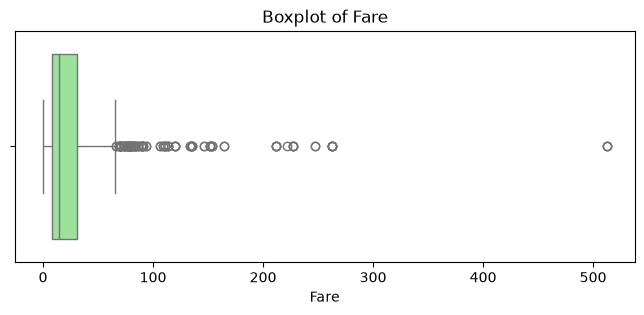

In [35]:
plt.figure(figsize = (8,3))
sns.boxplot(x = df["Fare"], color = "lightgreen")
plt.title("Boxplot of Fare")
plt.xlabel("Fare") 
plt.show()

# Categorical Feature Analysis

## Survival Count

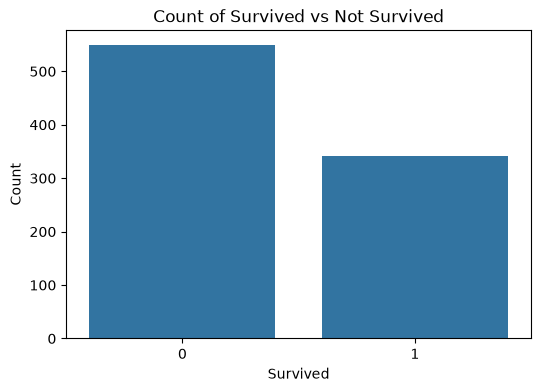

In [37]:
plt.figure(figsize = (6,4))
sns.countplot(x = "Survived", data = df)
plt.title("Count of Survived vs Not Survived")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

## Passenger Gender Distribution

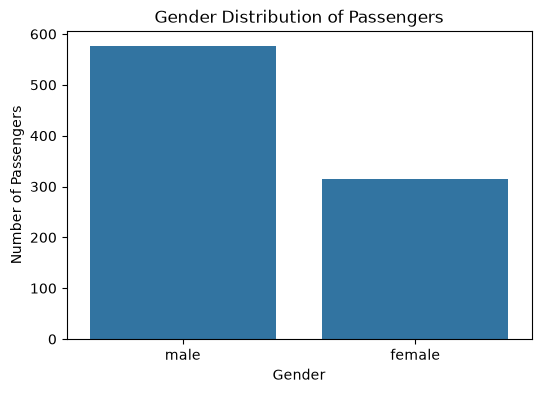

In [39]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sex")

plt.title("Gender Distribution of Passengers")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

In [46]:
df["Sex"].value_counts()
df["Sex"].value_counts(normalize = True)*100

Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64

## Passenger Class Distribution

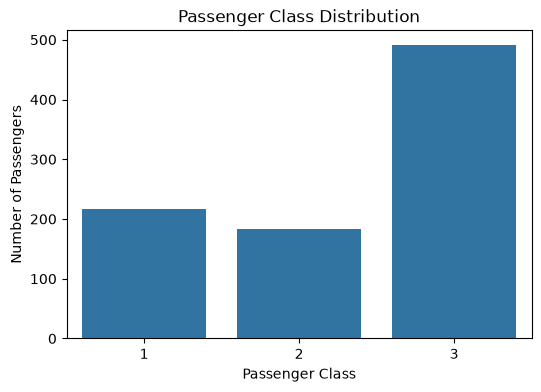

In [48]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pclass")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

In [50]:
df["Pclass"].value_counts()
df["Pclass"].value_counts(normalize = True)*100

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64

# Bivariate Analysis

## Survival by Gender

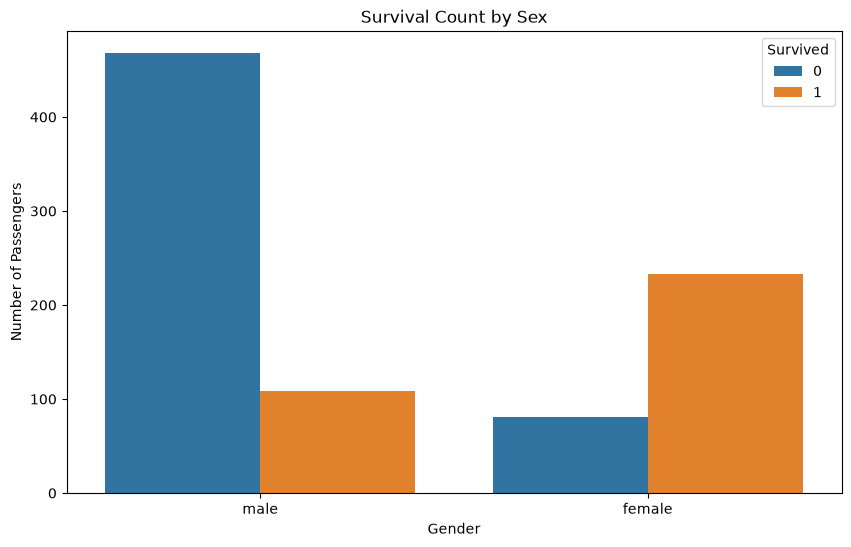

In [55]:
plt.figure(figsize = (10,6))
sns.countplot(x = "Sex" , hue = "Survived" , data = df)
plt.title("Survival Count by Sex")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

In [57]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


Relation blw Pclass and Survived

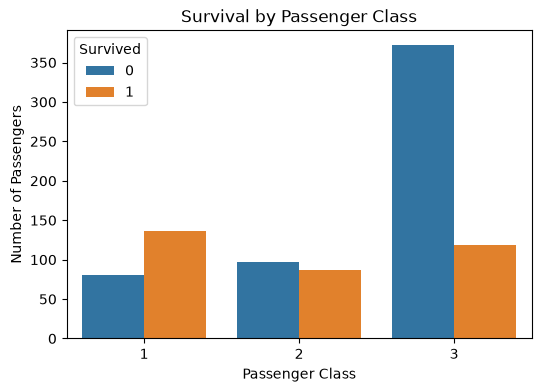

In [59]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

## Relationship Between Age and Fare

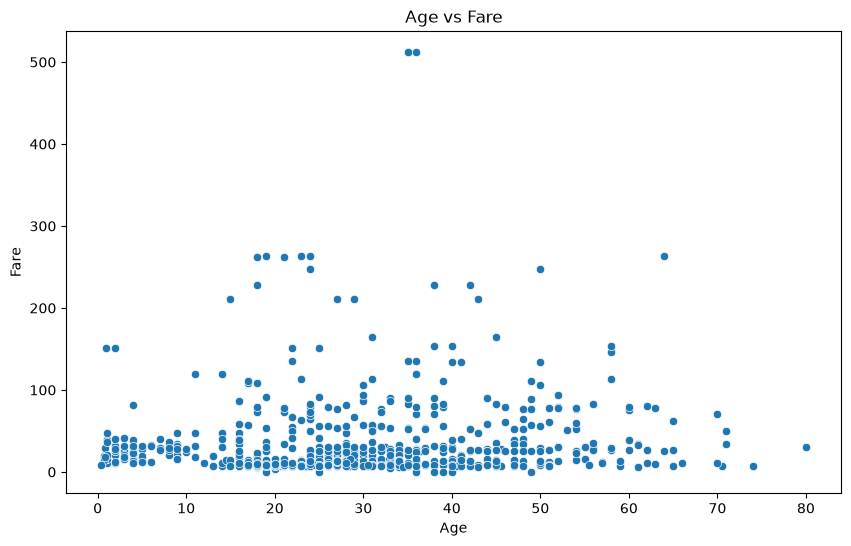

In [65]:
plt.figure(figsize = (10 , 6))
sns.scatterplot(data = df , x = "Age" , y = "Fare")
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

In [78]:
corr_matrix = df.drop("PassengerId", axis=1).corr(numeric_only=True)
corr_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


## Correlation Heatmap

Text(0.5, 1.0, 'Correlation Heatmap')

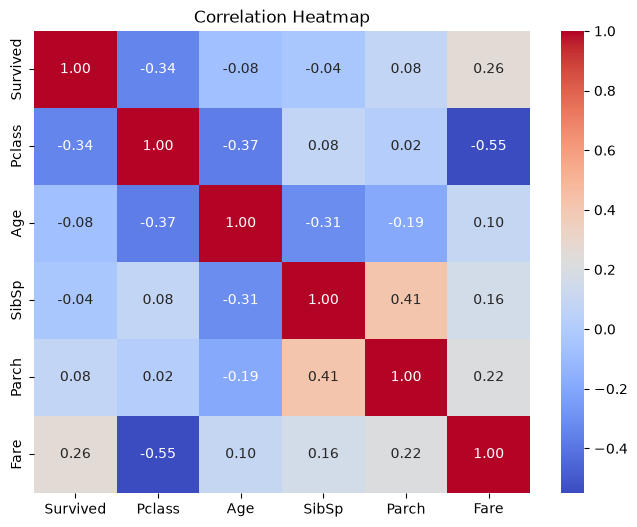

In [76]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix , annot = True , cmap = "coolwarm" , fmt = ".2f")
plt.title("Correlation Heatmap")

## Pair Plot

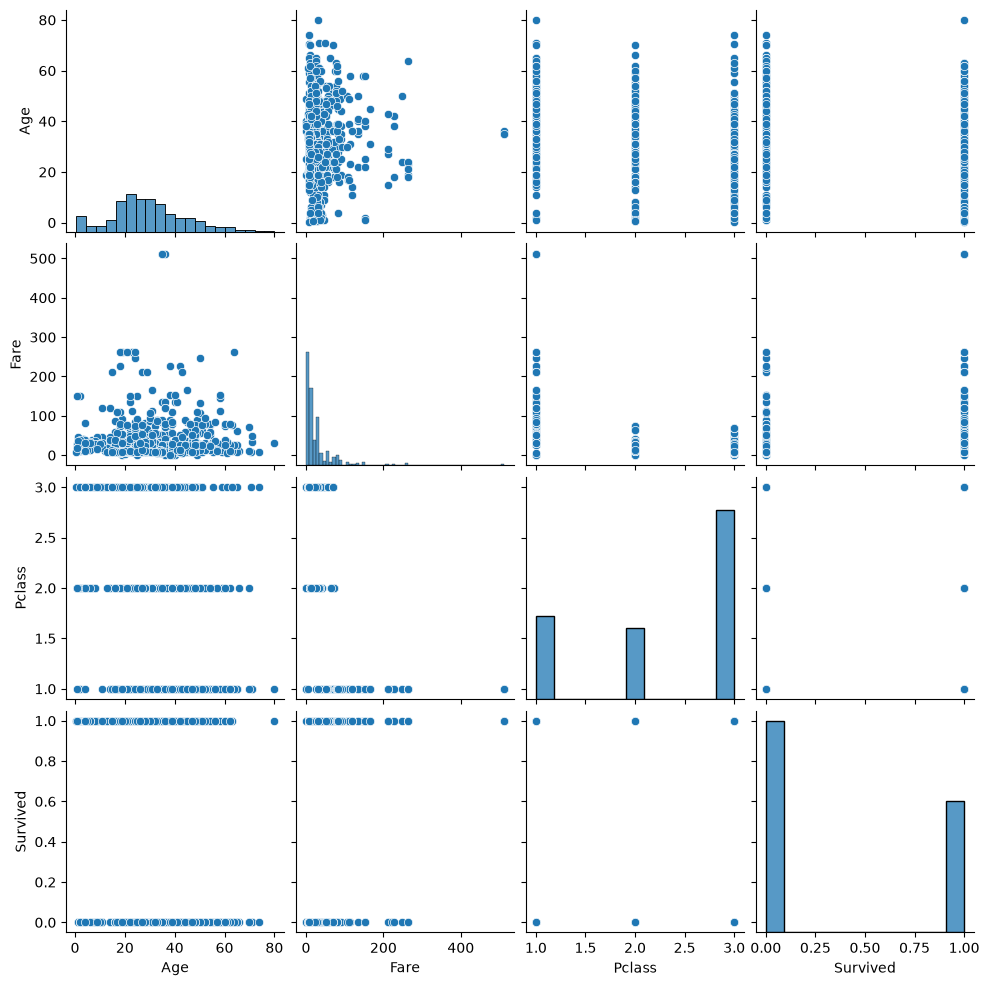

In [80]:
sns.pairplot(
    df[["Age", "Fare", "Pclass", "Survived"]],
    diag_kind="hist"
)

plt.show()

# Overall EDA Summary

- The dataset contains missing values in the `Age`, `Cabin`, and `Embarked` columns, with `Cabin` having the highest number of missing values.
- Most passengers were young adults between 20 and 30 years of age.
- Passenger fares are highly right-skewed, with a small number of expensive tickets creating several valid outliers.
- More passengers did not survive than survived.
- Male passengers were more numerous, but female passengers had a significantly higher survival rate.
- Third-class passengers formed the largest group, while first-class passengers had the highest survival rate.
- Passenger class and fare show a moderate negative correlation, whereas age has very little correlation with other numerical features.
- No strong relationship exists between passenger age and ticket fare.
- Overall, **Gender**, **Passenger Class**, and **Fare** appear to be the most influential features related to passenger survival.